Threads=1, Time(min)=0.08, CPU=15.0%
Threads=2, Time(min)=0.09, CPU=100.0%
Threads=3, Time(min)=0.05, CPU=100.0%
Threads=4, Time(min)=0.09, CPU=100.0%
Threads=5, Time(min)=0.05, CPU=100.0%
Threads=6, Time(min)=0.05, CPU=100.0%
Threads=7, Time(min)=0.05, CPU=100.0%
Threads=8, Time(min)=0.08, CPU=100.0%

Result Table:
T=1 -> 0.08 min
T=2 -> 0.09 min
T=3 -> 0.05 min
T=4 -> 0.09 min
T=5 -> 0.05 min
T=6 -> 0.05 min
T=7 -> 0.05 min
T=8 -> 0.08 min


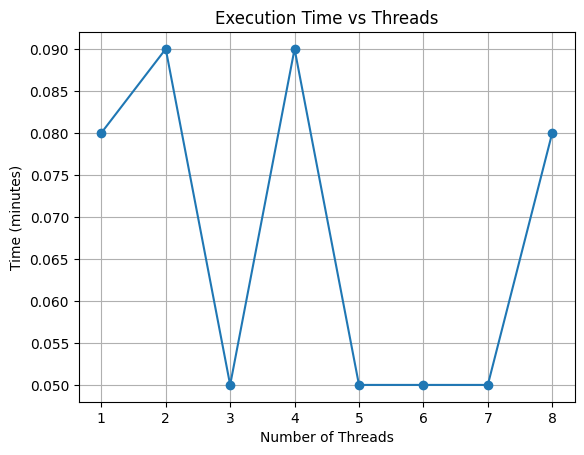

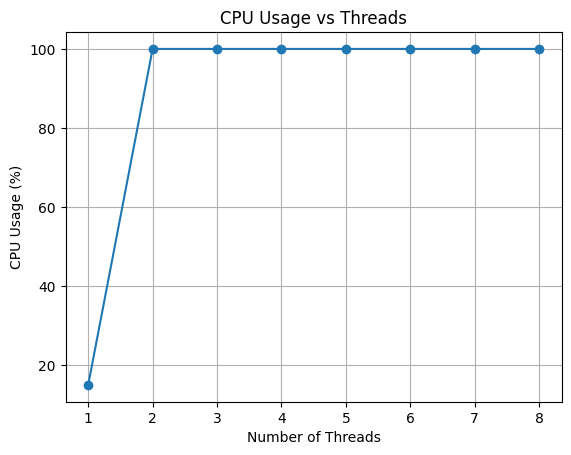

In [2]:
import numpy as np
import time
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor
import psutil
import os

# SETTINGS
NUM_MATRICES = 50
SIZE = 1000
MAX_THREADS = 8

# GENERATE DATA
constant_matrix = np.random.rand(SIZE, SIZE)
matrices = [np.random.rand(SIZE, SIZE) for _ in range(NUM_MATRICES)]

# FUNCTION
def multiply_matrix(m):
    return np.dot(m, constant_matrix)

# RUN EXPERIMENT
thread_counts = list(range(1, MAX_THREADS + 1))
times = []
cpu_usage = []

for t in thread_counts:
    start = time.time()

    with ThreadPoolExecutor(max_workers=t) as executor:
        list(executor.map(multiply_matrix, matrices))

    end = time.time()

    elapsed = (end - start) / 60
    times.append(round(elapsed, 2))

    cpu_usage.append(psutil.cpu_percent())

    print(f"Threads={t}, Time(min)={elapsed:.2f}, CPU={cpu_usage[-1]}%")

# RESULT TABLE
print("\nResult Table:")
for i in range(len(thread_counts)):
    print(f"T={thread_counts[i]} -> {times[i]} min")

# GRAPH
plt.figure()
plt.plot(thread_counts, times, marker='o')
plt.xlabel("Number of Threads")
plt.ylabel("Time (minutes)")
plt.title("Execution Time vs Threads")
plt.grid()
plt.show()

# USAGE GRAPH
plt.figure()
plt.plot(thread_counts, cpu_usage, marker='o')
plt.xlabel("Number of Threads")
plt.ylabel("CPU Usage (%)")
plt.title("CPU Usage vs Threads")
plt.grid()
plt.show()